In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import pickle

from pprint import pprint

file_dir = 'thinker-20250623-172121-3017184-0/video_stat.npy'
data_dir = os.path.join('../test', file_dir)

In [2]:
print(data_dir)

../test/thinker-20250623-172121-3017184-0/video_stat.npy


In [3]:
data = (np.load(data_dir, allow_pickle=True)).item()

print('data.keys():', data.keys())
print('real image data length:', len(data['real_imgs']))
print('imagination image data length:', len(data['im_imgs']))


data.keys(): dict_keys(['real_imgs', 'im_imgs', 'status', 'tree_reps'])
real image data length: 18514
imagination image data length: 18514


# im_image: list

In [4]:
data['im_imgs']

AttributeError: 'list' object has no attribute 'shape'

# tree_reps: list


### action_seq 분석

In [4]:
# action_seq의 구조를 더 자세히 분석해보겠습니다
print("action_seq 형태:", data['tree_reps']['action_seq'].shape)
print("\n첫 10개 샘플의 action_seq:")
for i in range(10):
    action_seq = data['tree_reps']['action_seq'][i]
    print(f"샘플 {i}: 합계={action_seq.sum():.2f}, 0이 아닌 값의 개수={np.count_nonzero(action_seq)}")
    if np.count_nonzero(action_seq) > 0:
        print(f"       0이 아닌 값의 위치: {np.nonzero(action_seq)[0]}")
        print(f"       0이 아닌 값: {action_seq[action_seq != 0]}")
    print()

# action_seq를 6개씩 그룹으로 나누어 분석
print("66차원을 6개씩 나누어 분석 (11개 그룹):")
sample_idx = 0
action_seq_sample = data['tree_reps']['action_seq'][sample_idx]
for group in range(11):
    start_idx = group * 6
    end_idx = start_idx + 6
    group_values = action_seq_sample[start_idx:end_idx]
    print(f"그룹 {group} (인덱스 {start_idx}-{end_idx-1}): {group_values}")


action_seq 형태: (18514, 66)

첫 10개 샘플의 action_seq:
샘플 0: 합계=1.00, 0이 아닌 값의 개수=1
       0이 아닌 값의 위치: [0]
       0이 아닌 값: [1.]

샘플 1: 합계=2.00, 0이 아닌 값의 개수=2
       0이 아닌 값의 위치: [ 0 11]
       0이 아닌 값: [1. 1.]

샘플 2: 합계=3.00, 0이 아닌 값의 개수=3
       0이 아닌 값의 위치: [ 0 11 13]
       0이 아닌 값: [1. 1. 1.]

샘플 3: 합계=4.00, 0이 아닌 값의 개수=4
       0이 아닌 값의 위치: [ 0 11 13 19]
       0이 아닌 값: [1. 1. 1. 1.]

샘플 4: 합계=5.00, 0이 아닌 값의 개수=5
       0이 아닌 값의 위치: [ 0 11 13 19 28]
       0이 아닌 값: [1. 1. 1. 1. 1.]

샘플 5: 합계=6.00, 0이 아닌 값의 개수=6
       0이 아닌 값의 위치: [ 0 11 13 19 28 34]
       0이 아닌 값: [1. 1. 1. 1. 1. 1.]

샘플 6: 합계=7.00, 0이 아닌 값의 개수=7
       0이 아닌 값의 위치: [ 0 11 13 19 28 34 40]
       0이 아닌 값: [1. 1. 1. 1. 1. 1. 1.]

샘플 7: 합계=8.00, 0이 아닌 값의 개수=8
       0이 아닌 값의 위치: [ 0 11 13 19 28 34 40 46]
       0이 아닌 값: [1. 1. 1. 1. 1. 1. 1. 1.]

샘플 8: 합계=9.00, 0이 아닌 값의 개수=9
       0이 아닌 값의 위치: [ 0 11 13 19 28 34 40 46 52]
       0이 아닌 값: [1. 1. 1. 1. 1. 1. 1. 1. 1.]

샘플 9: 합계=10.00, 0이 아닌 값의 개수=10
       0이 아닌 값의 위치: 

### rollout return 분석

In [5]:
# rollout_return과 max_rollout_return의 차이 분석
print("=== rollout_return vs max_rollout_return 분석 ===")

rollout_return = data['tree_reps']['rollout_return']
max_rollout_return = data['tree_reps']['max_rollout_return']

print(f"rollout_return 형태: {rollout_return.shape}")
print(f"max_rollout_return 형태: {max_rollout_return.shape}")

print("\n=== 통계 정보 ===")
print(f"rollout_return - 평균: {rollout_return.mean():.4f}, 표준편차: {rollout_return.std():.4f}")
print(f"rollout_return - 최소: {rollout_return.min():.4f}, 최대: {rollout_return.max():.4f}")

print(f"max_rollout_return - 평균: {max_rollout_return.mean():.4f}, 표준편차: {max_rollout_return.std():.4f}")
print(f"max_rollout_return - 최소: {max_rollout_return.min():.4f}, 최대: {max_rollout_return.max():.4f}")

print("\n=== 첫 20개 샘플 비교 ===")
print("Index | rollout_return | max_rollout_return | 차이")
print("------|----------------|--------------------|---------")
for i in range(20):
    rr = rollout_return[i, 0]
    mrr = max_rollout_return[i, 0]
    diff = mrr - rr
    print(f"{i:5d} | {rr:13.6f} | {mrr:17.6f} | {diff:7.6f}")

# 두 값이 같은 경우와 다른 경우 분석
same_count = np.sum(np.abs(rollout_return - max_rollout_return) < 1e-6)
total_count = len(rollout_return)
print(f"\n=== 동일성 분석 ===")
print(f"같은 값인 경우: {same_count}/{total_count} ({same_count/total_count*100:.2f}%)")
print(f"다른 값인 경우: {total_count-same_count}/{total_count} ({(total_count-same_count)/total_count*100:.2f}%)")

# max_rollout_return >= rollout_return인지 확인
greater_equal = np.sum(max_rollout_return >= rollout_return - 1e-6)
print(f"max_rollout_return >= rollout_return: {greater_equal}/{total_count} ({greater_equal/total_count*100:.2f}%)")

# 차이의 분포
diff = max_rollout_return - rollout_return
print(f"\n차이 (max - rollout) 통계:")
print(f"평균: {diff.mean():.6f}, 표준편차: {diff.std():.6f}")
print(f"최소: {diff.min():.6f}, 최대: {diff.max():.6f}")

=== rollout_return vs max_rollout_return 분석 ===
rollout_return 형태: (18514, 1)
max_rollout_return 형태: (18514, 1)

=== 통계 정보 ===
rollout_return - 평균: 3.2437, 표준편차: 1.7876
rollout_return - 최소: -0.0483, 최대: 6.6968
max_rollout_return - 평균: 3.5306, 표준편차: 1.8491
max_rollout_return - 최소: -0.0207, 최대: 6.9398

=== 첫 20개 샘플 비교 ===
Index | rollout_return | max_rollout_return | 차이
------|----------------|--------------------|---------
    0 |      3.741872 |          3.741872 | 0.000000
    1 |      3.688143 |          3.741872 | 0.053729
    2 |      3.826667 |          3.826667 | 0.000000
    3 |      3.836129 |          3.836129 | 0.000000
    4 |      3.924313 |          3.924313 | 0.000000
    5 |      3.880948 |          3.924313 | 0.043365
    6 |      3.848524 |          3.924313 | 0.075789
    7 |      3.788929 |          3.924313 | 0.135384
    8 |      3.776503 |          3.924313 | 0.147810
    9 |      3.757729 |          3.924313 | 0.166584
   10 |      3.708221 |          3.924313 | 

In [10]:
# blen(data['status'])
data['tree_reps']['action_seq'].shape

# action_seq의 구조를 더 자세히 분석해보겠습니다
print("action_seq 형태:", data['tree_reps']['action_seq'].shape)
print("\n첫 10개 샘플의 action_seq:")
for i in range(10):
    action_seq = data['tree_reps']['action_seq'][i]
    print(f"샘플 {i}: 합계={action_seq.sum():.2f}, 0이 아닌 값의 개수={np.count_nonzero(action_seq)}")
    if np.count_nonzero(action_seq) > 0:
        print(f"       0이 아닌 값의 위치: {np.nonzero(action_seq)[0]}")
        print(f"       0이 아닌 값: {action_seq[action_seq != 0]}")
    print()

# action_seq를 6개씩 그룹으로 나누어 분석
print("66차원을 6개씩 나누어 분석 (11개 그룹):")
sample_idx = 0
action_seq_sample = data['tree_reps']['action_seq'][sample_idx]
for group in range(11):
    start_idx = group * 6
    end_idx = start_idx + 6
    group_values = action_seq_sample[start_idx:end_idx]
    print(f"그룹 {group} (인덱스 {start_idx}-{end_idx-1}): {group_values}")

(18514, 66)

In [6]:
# rollout_return과 status의 관계 분석
print("=== rollout_return과 status 관계 분석 ===")

# Status별로 rollout_return과 max_rollout_return 분석
status_array = np.array(data['status'])
rollout_return = data['tree_reps']['rollout_return']
max_rollout_return = data['tree_reps']['max_rollout_return']

for status_val in [0, 1, 2, 3]:
    indices = np.where(status_array == status_val)[0]
    if len(indices) > 0:
        status_name = {
            0: "실제 스텝(real step)",
            1: "리셋(reset)", 
            2: "상상 스텝(imaginary step)",
            3: "강제 리셋(force reset)"
        }[status_val]
        
        rr_status = rollout_return[indices]
        mrr_status = max_rollout_return[indices]
        
        print(f"\n--- Status {status_val}: {status_name} ({len(indices)}개) ---")
        print(f"rollout_return - 평균: {rr_status.mean():.4f}, 표준편차: {rr_status.std():.4f}")
        print(f"max_rollout_return - 평균: {mrr_status.mean():.4f}, 표준편차: {mrr_status.std():.4f}")
        print(f"차이 평균: {(mrr_status - rr_status).mean():.4f}")
        
        # 처음 5개 예시
        print("처음 5개 예시:")
        for i in range(min(5, len(indices))):
            idx = indices[i]
            print(f"  인덱스 {idx}: rollout={rollout_return[idx,0]:.4f}, max={max_rollout_return[idx,0]:.4f}")

print("\n=== 연속된 스텝들의 관계 ===")
# 연속된 몇 개 스텝을 보여주기
print("연속된 20개 스텝의 status와 rollout 값:")
print("Index | Status | Type                | rollout_return | max_rollout_return")
print("------|--------|---------------------|----------------|-------------------")
for i in range(20):
    status_val = data['status'][i]
    status_name = {
        0: "real step",
        1: "reset", 
        2: "imaginary step",
        3: "force reset"
    }.get(status_val, "unknown")
    
    rr = rollout_return[i, 0]
    mrr = max_rollout_return[i, 0]
    print(f"{i:5d} | {status_val:6d} | {status_name:19s} | {rr:14.6f} | {mrr:17.6f}")

# Real step 시작점들 확인
real_step_indices = np.where(status_array == 0)[0]
print(f"\n=== Real Step 주변 분석 ===")
print("처음 3개 real step 주변의 imaginary step들:")

for i, real_idx in enumerate(real_step_indices[:3]):
    print(f"\n{i+1}번째 Real Step (인덱스 {real_idx}) 주변:")
    start_idx = max(0, real_idx - 2)
    end_idx = min(len(status_array), real_idx + 10)
    
    for j in range(start_idx, end_idx):
        status_val = data['status'][j]
        status_name = {0: "REAL", 1: "RESET", 2: "IMAG", 3: "FORCE"}[status_val]
        rr = rollout_return[j, 0]
        mrr = max_rollout_return[j, 0]
        marker = " <-- Real Step" if j == real_idx else ""
        print(f"  {j:5d}: {status_name} | rollout={rr:7.4f} | max={mrr:7.4f}{marker}")


=== rollout_return과 status 관계 분석 ===

--- Status 0: 실제 스텝(real step) (834개) ---
rollout_return - 평균: 3.2810, 표준편차: 1.7467
max_rollout_return - 평균: 3.5058, 표준편차: 1.8198
차이 평균: 0.2248
처음 5개 예시:
  인덱스 0: rollout=3.7419, max=3.7419
  인덱스 21: rollout=3.8508, max=3.9497
  인덱스 43: rollout=3.9735, max=4.0326
  인덱스 65: rollout=3.9547, max=4.1206
  인덱스 88: rollout=4.0651, max=4.1724

--- Status 1: 리셋(reset) (238개) ---
rollout_return - 평균: 0.0975, 표준편차: 0.5348
max_rollout_return - 평균: 0.1662, 표준편차: 0.6332
차이 평균: 0.0687
처음 5개 예시:
  인덱스 72: rollout=3.8744, max=4.1206
  인덱스 130: rollout=3.8264, max=4.1957
  인덱스 1243: rollout=6.2928, max=6.2928
  인덱스 2478: rollout=0.6018, max=5.0308
  인덱스 2506: rollout=0.1668, max=0.6000

--- Status 2: 상상 스텝(imaginary step) (15827개) ---
rollout_return - 평균: 3.2768, 표준편차: 1.7694
max_rollout_return - 평균: 3.5700, 표준편차: 1.8260
차이 평균: 0.2932
처음 5개 예시:
  인덱스 1: rollout=3.6881, max=3.7419
  인덱스 2: rollout=3.8267, max=3.8267
  인덱스 3: rollout=3.8361, max=3.8361
  인덱스 4: rollo

In [8]:
import numpy as np
data = (np.load('../test/thinker-20250623-172121-3017184-0/video_stat.npy', allow_pickle=True)).item()

print('=== Action Seq 스텝별 분석 ===')

status_array = np.array(data['status'])
action_seq_data = data['tree_reps']['action_seq']

# 각 status별로 action_seq 패턴 분석
for status_val in [0, 2, 3, 1]:  # real, imaginary, force reset, reset 순서
    indices = np.where(status_array == status_val)[0][:5]  # 처음 5개만
    
    status_name = {
        0: 'Real Step',
        1: 'Reset', 
        2: 'Imaginary Step',
        3: 'Force Reset'
    }[status_val]
    
    print(f'\n--- {status_name} ---')
    for i, idx in enumerate(indices):
        action_seq = action_seq_data[idx]
        nonzero_count = np.count_nonzero(action_seq)
        nonzero_positions = np.nonzero(action_seq)[0]
        
        print(f'  인덱스 {idx}: 0이 아닌 값 {nonzero_count}개')
        if nonzero_count > 0 and nonzero_count <= 10:
            print(f'    위치: {nonzero_positions}')
        elif nonzero_count > 10:
            print(f'    위치 (처음 10개): {nonzero_positions[:10]}')

print('\n=== 연속된 스텝들의 Action Seq 변화 ===')
# 첫 번째 stage의 연속된 스텝들 보기
print('첫 20개 스텝의 action_seq 패턴:')
print('Index | Status | NonZero Count | First 5 positions')
print('------|--------|---------------|------------------')

for i in range(20):
    status_val = status_array[i]
    action_seq = action_seq_data[i]
    nonzero_count = np.count_nonzero(action_seq)
    nonzero_positions = np.nonzero(action_seq)[0]
    
    status_char = {0: 'R', 1: 'Re', 2: 'I', 3: 'F'}[status_val]
    
    if len(nonzero_positions) > 0:
        first_positions = nonzero_positions[:5]
        pos_str = str(list(first_positions)).replace('[', '').replace(']', '')
    else:
        pos_str = 'None'
    
    print(f'{i:5d} | {status_char:6s} | {nonzero_count:13d} | {pos_str}')

=== Action Seq 스텝별 분석 ===

--- Real Step ---
  인덱스 0: 0이 아닌 값 1개
    위치: [0]
  인덱스 21: 0이 아닌 값 1개
    위치: [4]
  인덱스 43: 0이 아닌 값 1개
    위치: [4]
  인덱스 65: 0이 아닌 값 1개
    위치: [4]
  인덱스 88: 0이 아닌 값 1개
    위치: [4]

--- Imaginary Step ---
  인덱스 1: 0이 아닌 값 2개
    위치: [ 0 11]
  인덱스 2: 0이 아닌 값 3개
    위치: [ 0 11 13]
  인덱스 3: 0이 아닌 값 4개
    위치: [ 0 11 13 19]
  인덱스 4: 0이 아닌 값 5개
    위치: [ 0 11 13 19 28]
  인덱스 5: 0이 아닌 값 6개
    위치: [ 0 11 13 19 28 34]

--- Force Reset ---
  인덱스 11: 0이 아닌 값 11개
    위치 (처음 10개): [ 0 11 13 19 28 34 40 46 52 58]
  인덱스 22: 0이 아닌 값 1개
    위치: [4]
  인덱스 33: 0이 아닌 값 11개
    위치 (처음 10개): [ 4 11 13 19 28 34 40 46 52 58]
  인덱스 44: 0이 아닌 값 1개
    위치: [4]
  인덱스 55: 0이 아닌 값 11개
    위치 (처음 10개): [ 4 11 13 22 28 34 40 46 52 58]

--- Reset ---
  인덱스 72: 0이 아닌 값 6개
    위치: [ 4 11 13 22 28 34]
  인덱스 130: 0이 아닌 값 8개
    위치: [ 4 10 13 22 28 34 40 46]
  인덱스 1243: 0이 아닌 값 9개
    위치: [ 1 11 13 19 25 31 37 43 49]
  인덱스 2478: 0이 아닌 값 11개
    위치 (처음 10개): [ 5 11 13 22 28 31 37 45 49 58]
  인덱

In [7]:
import numpy as np
data = (np.load('../test/thinker-20250623-172121-3017184-0/video_stat.npy', allow_pickle=True)).item()

print('=== Planning Session (Stage) 분석 ===')

# Real step들의 인덱스 찾기
status_array = np.array(data['status'])
real_step_indices = np.where(status_array == 0)[0]

print(f'전체 Real step 개수: {len(real_step_indices)}')
print(f'첫 10개 Real step 인덱스: {real_step_indices[:10]}')

# Real step 간 간격 분석
print('\n=== Real Step 간 간격 분석 ===')
intervals = []
for i in range(1, min(15, len(real_step_indices))):
    interval = real_step_indices[i] - real_step_indices[i-1]
    intervals.append(interval)
    print(f'Real Step {i-1} → {i}: 인덱스 {real_step_indices[i-1]} → {real_step_indices[i]} (간격: {interval})')

intervals = np.array(intervals)
print(f'\n간격 통계:')
print(f'평균 간격: {intervals.mean():.2f}')
print(f'최소 간격: {intervals.min()}')
print(f'최대 간격: {intervals.max()}')
print(f'표준편차: {intervals.std():.2f}')

# rec_t=20과 비교
print(f'\nrec_t=20과 비교:')
print(f'간격이 21인 경우: {np.sum(intervals == 21)}개')
print(f'간격이 22인 경우: {np.sum(intervals == 22)}개')
print(f'간격이 20인 경우: {np.sum(intervals == 20)}개')
print(f'간격이 19-23 범위인 경우: {np.sum((intervals >= 19) & (intervals <= 23))}개')

=== Planning Session (Stage) 분석 ===
전체 Real step 개수: 834
첫 10개 Real step 인덱스: [  0  21  43  65  88 110 133 155 177 199]

=== Real Step 간 간격 분석 ===
Real Step 0 → 1: 인덱스 0 → 21 (간격: 21)
Real Step 1 → 2: 인덱스 21 → 43 (간격: 22)
Real Step 2 → 3: 인덱스 43 → 65 (간격: 22)
Real Step 3 → 4: 인덱스 65 → 88 (간격: 23)
Real Step 4 → 5: 인덱스 88 → 110 (간격: 22)
Real Step 5 → 6: 인덱스 110 → 133 (간격: 23)
Real Step 6 → 7: 인덱스 133 → 155 (간격: 22)
Real Step 7 → 8: 인덱스 155 → 177 (간격: 22)
Real Step 8 → 9: 인덱스 177 → 199 (간격: 22)
Real Step 9 → 10: 인덱스 199 → 221 (간격: 22)
Real Step 10 → 11: 인덱스 221 → 243 (간격: 22)
Real Step 11 → 12: 인덱스 243 → 265 (간격: 22)
Real Step 12 → 13: 인덱스 265 → 287 (간격: 22)
Real Step 13 → 14: 인덱스 287 → 309 (간격: 22)

간격 통계:
평균 간격: 22.07
최소 간격: 21
최대 간격: 23
표준편차: 0.46

rec_t=20과 비교:
간격이 21인 경우: 1개
간격이 22인 경우: 11개
간격이 20인 경우: 0개
간격이 19-23 범위인 경우: 14개


In [5]:
# tree_reps 구조 확인
tree_reps = data['tree_reps']
print(f'Tree reps type: {type(tree_reps)}')
if isinstance(tree_reps, dict):
    print(f'Tree reps keys: {list(tree_reps.keys())}')
    for key in tree_reps.keys():
        print(f'  {key}: shape {tree_reps[key].shape}, type {type(tree_reps[key])}')
else:
    print(f'Tree reps shape: {tree_reps.shape}')

# rollout_return과 max_rollout_return 추출
if 'rollout_return' in tree_reps and 'max_rollout_return' in tree_reps:
    rollout_return = tree_reps['rollout_return']
    max_rollout_return = tree_reps['max_rollout_return']
else:
    # 이전 분석에서 컬럼 65, 66이었다면
    rollout_return = tree_reps[:, 65] if hasattr(tree_reps, 'shape') else None
    max_rollout_return = tree_reps[:, 66] if hasattr(tree_reps, 'shape') else None

print(f'\nRollout return shape: {rollout_return.shape if rollout_return is not None else None}')
print(f'Max rollout return shape: {max_rollout_return.shape if max_rollout_return is not None else None}')

Tree reps type: <class 'dict'>
Tree reps keys: ['root_action', 'root_r', 'root_d', 'root_v', 'root_policy', 'root_qs_mean', 'root_qs_max', 'root_ns', 'root_trail_r', 'rollout_return', 'max_rollout_return', 'root_raw_action', 'cur_action', 'cur_r', 'cur_d', 'cur_v', 'cur_policy', 'cur_qs_mean', 'cur_qs_max', 'cur_ns', 'cur_raw_action', 'cur_reset', 'k', 'deprec', 'action_seq']
  root_action: shape (18514, 6), type <class 'numpy.ndarray'>
  root_r: shape (18514, 1), type <class 'numpy.ndarray'>
  root_d: shape (18514, 1), type <class 'numpy.ndarray'>
  root_v: shape (18514, 1), type <class 'numpy.ndarray'>
  root_policy: shape (18514, 6), type <class 'numpy.ndarray'>
  root_qs_mean: shape (18514, 6), type <class 'numpy.ndarray'>
  root_qs_max: shape (18514, 6), type <class 'numpy.ndarray'>
  root_ns: shape (18514, 6), type <class 'numpy.ndarray'>
  root_trail_r: shape (18514, 1), type <class 'numpy.ndarray'>
  rollout_return: shape (18514, 1), type <class 'numpy.ndarray'>
  max_rollout_r

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# 데이터 로드
status_array = np.array(data['status'])
rollout_return = data['tree_reps']['rollout_return']
max_rollout_return = data['tree_reps']['max_rollout_return']

# Real step 인덱스들 찾기
real_step_indices = np.where(status_array == 0)[0]

print("=== max_rollout_return 업데이트 패턴 분석 ===")
print(f"전체 Real step 개수: {len(real_step_indices)}")
print(f"첫 몇 개 Real step 인덱스: {real_step_indices[:10]}")

# 첫 3개 stage만 자세히 분석
print("\n=== 각 Stage별 상세 분석 (첫 3개 stage) ===")

for stage_idx in range(min(3, len(real_step_indices) - 1)):
    start_real_idx = real_step_indices[stage_idx]
    end_real_idx = real_step_indices[stage_idx + 1]
    stage_length = end_real_idx - start_real_idx
    
    print(f"\n{'='*50}")
    print(f"Stage {stage_idx + 1}: 인덱스 {start_real_idx} → {end_real_idx} (길이: {stage_length})")
    print(f"{'='*50}")
    
    # 이 stage의 모든 스텝들 분석
    stage_indices = list(range(start_real_idx, end_real_idx))
    stage_statuses = [status_array[i] for i in stage_indices]
    stage_rollout = [rollout_return[i, 0] for i in stage_indices]
    stage_max_rollout = [max_rollout_return[i, 0] for i in stage_indices]
    
    print(f"Real step 시작값:")
    print(f"  rollout_return: {stage_rollout[0]:.6f}")
    print(f"  max_rollout_return: {stage_max_rollout[0]:.6f}")
    
    # 각 스텝별 상세 정보 (처음 15개까지)
    print(f"\n단계별 상세 정보 (처음 15개):")
    print("Step | Status | rollout_return | max_rollout_return | 차이     | Max변화")
    print("-"*70)
    
    prev_max = stage_max_rollout[0]
    max_updates = []
    
    for i in range(min(15, len(stage_indices))):
        status = stage_statuses[i]
        rollout = stage_rollout[i]
        max_val = stage_max_rollout[i]
        diff = max_val - rollout
        
        status_name = {0: 'R', 1: 'Re', 2: 'I', 3: 'F'}[status]
        
        # max값이 변했는지 확인
        max_change = ""
        if i > 0:
            if abs(max_val - prev_max) > 1e-6:
                if max_val > prev_max:
                    max_change = f"↑ +{max_val - prev_max:.6f}"
                    max_updates.append((i, prev_max, max_val))
                else:
                    max_change = f"↓ {max_val - prev_max:.6f}"
            prev_max = max_val
        
        print(f"{i:4d} | {status_name:6s} | {rollout:14.6f} | {max_val:14.6f} | {diff:8.6f} | {max_change}")
    
    # max값 업데이트 요약
    print(f"\nMax값 업데이트 요약:")
    print(f"  시작 max값: {stage_max_rollout[0]:.6f}")
    print(f"  최종 max값: {stage_max_rollout[-1]:.6f}")
    print(f"  전체 변화: {stage_max_rollout[-1] - stage_max_rollout[0]:.6f}")
    
    if max_updates:
        print(f"  업데이트 발생 횟수: {len(max_updates)}")
        for step, old_val, new_val in max_updates:
            print(f"    Step {step}: {old_val:.6f} → {new_val:.6f} (변화: +{new_val-old_val:.6f})")
    else:
        print(f"  ✓ 이 stage에서는 max값이 변하지 않음")
    
    # rollout_return == max_rollout_return인 시점들
    equal_points = []
    for i in range(len(stage_rollout)):
        if abs(stage_rollout[i] - stage_max_rollout[i]) < 1e-6:
            equal_points.append(i)
    
    print(f"  rollout == max인 시점들: {equal_points}")
    
    # 고유 max값 개수
    unique_max_values = len(set([round(x, 8) for x in stage_max_rollout]))
    print(f"  고유 max값 개수: {unique_max_values}")

=== max_rollout_return 업데이트 패턴 분석 ===
전체 Real step 개수: 834
첫 몇 개 Real step 인덱스: [  0  21  43  65  88 110 133 155 177 199]

=== 각 Stage별 상세 분석 (첫 3개 stage) ===

Stage 1: 인덱스 0 → 21 (길이: 21)
Real step 시작값:
  rollout_return: 3.741872
  max_rollout_return: 3.741872

단계별 상세 정보 (처음 15개):
Step | Status | rollout_return | max_rollout_return | 차이     | Max변화
----------------------------------------------------------------------
   0 | R      |       3.741872 |       3.741872 | 0.000000 | 
   1 | I      |       3.688143 |       3.741872 | 0.053729 | 
   2 | I      |       3.826667 |       3.826667 | 0.000000 | ↑ +0.084795
   3 | I      |       3.836129 |       3.836129 | 0.000000 | ↑ +0.009462
   4 | I      |       3.924313 |       3.924313 | 0.000000 | ↑ +0.088183
   5 | I      |       3.880948 |       3.924313 | 0.043365 | 
   6 | I      |       3.848524 |       3.924313 | 0.075789 | 
   7 | I      |       3.788929 |       3.924313 | 0.135384 | 
   8 | I      |       3.776503 |       3.924313 

In [13]:
# 전체 패턴 통계 분석 (에러 수정)
print(f"\n{'='*60}")
print("=== 전체 패턴 통계 분석 ===")
print(f"{'='*60}")

# 각 stage별로 max값이 일정한지 확인 (안전한 방법으로)
total_stages = len(real_step_indices) - 1
constant_stages = 0
variable_stages = 0
stage_analysis = []

print(f"총 분석할 stage 수: {total_stages}")

for stage_idx in range(total_stages):
    start_real_idx = real_step_indices[stage_idx]
    
    # 마지막 stage인 경우 처리
    if stage_idx == total_stages - 1:
        end_real_idx = len(status_array)  # 전체 데이터 끝까지
    else:
        end_real_idx = real_step_indices[stage_idx + 1]
    
    # 해당 stage의 max값들
    stage_max_values = [max_rollout_return[i, 0] for i in range(start_real_idx, end_real_idx)]
    stage_rollout_values = [rollout_return[i, 0] for i in range(start_real_idx, end_real_idx)]
    
    # 고유 max값 개수 계산 (더 정밀하게)
    rounded_max_values = [round(x, 8) for x in stage_max_values]
    unique_max_count = len(set(rounded_max_values))
    
    # max값이 업데이트되는 시점들 찾기
    max_update_count = 0
    for i in range(1, len(stage_max_values)):
        if abs(stage_max_values[i] - stage_max_values[i-1]) > 1e-8:
            max_update_count += 1
    
    # rollout == max인 시점 개수
    equal_count = sum(1 for r, m in zip(stage_rollout_values, stage_max_values) 
                     if abs(r - m) < 1e-8)
    
    stage_info = {
        'stage_idx': stage_idx,
        'start_idx': start_real_idx,
        'end_idx': end_real_idx,
        'length': end_real_idx - start_real_idx,
        'unique_max_count': unique_max_count,
        'max_update_count': max_update_count,
        'equal_count': equal_count,
        'start_max': stage_max_values[0],
        'end_max': stage_max_values[-1],
        'is_constant': unique_max_count == 1
    }
    
    stage_analysis.append(stage_info)
    
    if unique_max_count == 1:
        constant_stages += 1
    else:
        variable_stages += 1

print(f"\n분석 결과:")
print(f"Max값이 일정한 stage: {constant_stages}")
print(f"Max값이 변화하는 stage: {variable_stages}")

if total_stages > 0:
    print(f"일정한 stage 비율: {constant_stages/total_stages*100:.1f}%")
    print(f"변화하는 stage 비율: {variable_stages/total_stages*100:.1f}%")

# 변화하는 stage들의 상세 정보
print(f"\n=== 변화하는 Stage들의 상세 정보 ===")
variable_stage_info = [s for s in stage_analysis if not s['is_constant']]

if variable_stage_info:
    print(f"변화하는 stage들: {len(variable_stage_info)}개")
    print("Stage | 길이 | 업데이트횟수 | 시작Max | 최종Max | 변화량")
    print("-"*55)
    
    for info in variable_stage_info[:10]:  # 처음 10개만 표시
        change = info['end_max'] - info['start_max']
        print(f"{info['stage_idx']:5d} | {info['length']:4d} | {info['max_update_count']:10d} | "
              f"{info['start_max']:7.4f} | {info['end_max']:7.4f} | {change:+7.4f}")
else:
    print("변화하는 stage가 없습니다.")

# 업데이트 패턴 통계
all_update_counts = [s['max_update_count'] for s in stage_analysis]
print(f"\n=== 업데이트 패턴 통계 ===")
print(f"평균 업데이트 횟수: {np.mean(all_update_counts):.2f}")
print(f"최대 업데이트 횟수: {max(all_update_counts)}")
print(f"업데이트가 0회인 stage: {sum(1 for c in all_update_counts if c == 0)}개")
print(f"업데이트가 1회 이상인 stage: {sum(1 for c in all_update_counts if c > 0)}개")


=== 전체 패턴 통계 분석 ===
총 분석할 stage 수: 833

분석 결과:
Max값이 일정한 stage: 151
Max값이 변화하는 stage: 682
일정한 stage 비율: 18.1%
변화하는 stage 비율: 81.9%

=== 변화하는 Stage들의 상세 정보 ===
변화하는 stage들: 682개
Stage | 길이 | 업데이트횟수 | 시작Max | 최종Max | 변화량
-------------------------------------------------------
    0 |   21 |          3 |  3.7419 |  3.9243 | +0.1824
    1 |   22 |          1 |  3.9497 |  4.0359 | +0.0861
    2 |   22 |          2 |  4.0326 |  4.0759 | +0.0433
    3 |   23 |          1 |  4.1206 |  4.1320 | +0.0114
   27 |   22 |          2 |  4.0469 |  4.1320 | +0.0851
   30 |   22 |          3 |  5.1901 |  5.4351 | +0.2450
   31 |   22 |          2 |  5.4864 |  5.7619 | +0.2755
   32 |   22 |          2 |  5.8173 |  5.8132 | -0.0041
   33 |   22 |          1 |  5.8715 |  6.0921 | +0.2206
   34 |   22 |          3 |  5.9277 |  6.4927 | +0.5650

=== 업데이트 패턴 통계 ===
평균 업데이트 횟수: 3.12
최대 업데이트 횟수: 13
업데이트가 0회인 stage: 151개
업데이트가 1회 이상인 stage: 682개



=== Stage 간 연결성 분석 ===
Stage 1 → Stage 2:
  이전 stage 마지막 max: 3.924313
  다음 stage 시작 max: 3.949750
  연결 여부: ✗ 분리됨
Stage 2 → Stage 3:
  이전 stage 마지막 max: 4.035858
  다음 stage 시작 max: 4.032592
  연결 여부: ✗ 분리됨
Stage 3 → Stage 4:
  이전 stage 마지막 max: 4.075911
  다음 stage 시작 max: 4.120579
  연결 여부: ✗ 분리됨
Stage 4 → Stage 5:
  이전 stage 마지막 max: 4.131952
  다음 stage 시작 max: 4.172425
  연결 여부: ✗ 분리됨
Stage 5 → Stage 6:
  이전 stage 마지막 max: 4.172425
  다음 stage 시작 max: 4.195721
  연결 여부: ✗ 분리됨
Stage 6 → Stage 7:
  이전 stage 마지막 max: 4.195721
  다음 stage 시작 max: 4.128043
  연결 여부: ✗ 분리됨
Stage 7 → Stage 8:
  이전 stage 마지막 max: 4.128043
  다음 stage 시작 max: 4.151090
  연결 여부: ✗ 분리됨
Stage 8 → Stage 9:
  이전 stage 마지막 max: 4.151090
  다음 stage 시작 max: 4.172425
  연결 여부: ✗ 분리됨
Stage 9 → Stage 10:
  이전 stage 마지막 max: 4.172425
  다음 stage 시작 max: 4.195721
  연결 여부: ✗ 분리됨
Stage 10 → Stage 11:
  이전 stage 마지막 max: 4.195721
  다음 stage 시작 max: 4.128043
  연결 여부: ✗ 분리됨

Stage 간 연결성 요약:
연결된 stage 전환: 0/10 (0.0%)

=== 최종 결론: max_roll

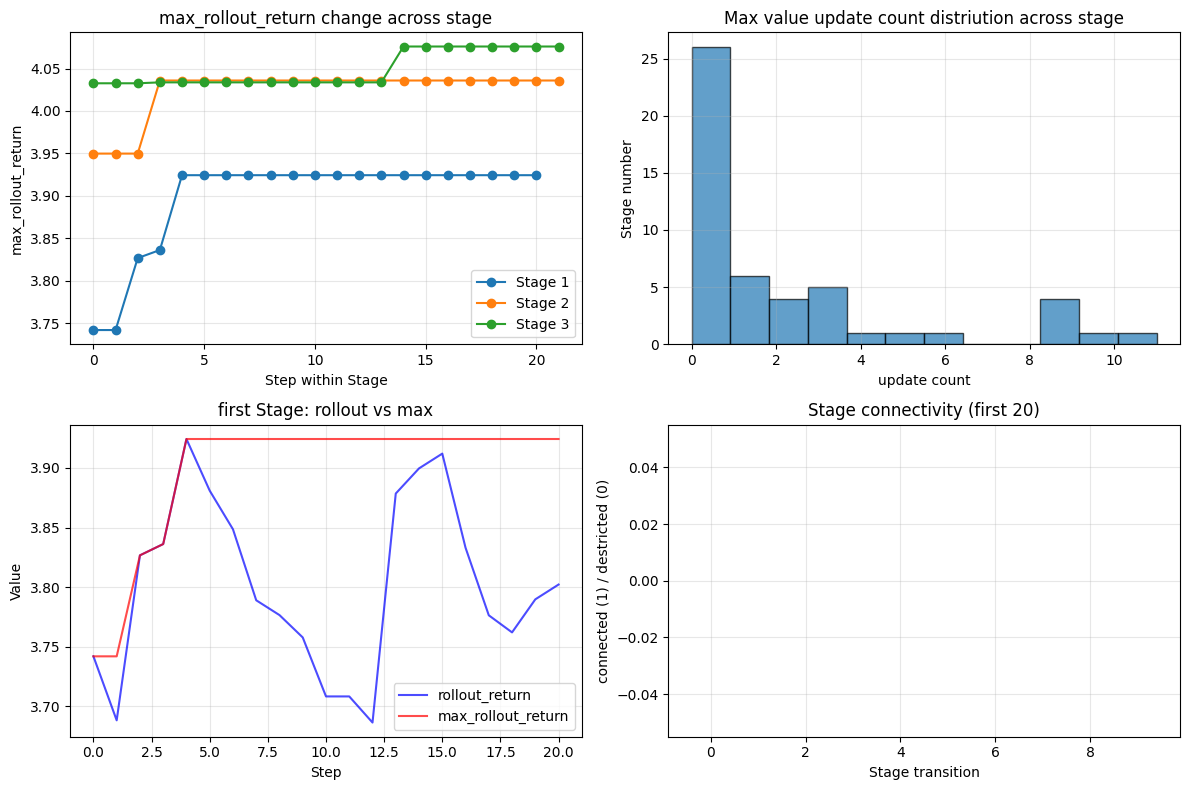

In [15]:
# Stage 간 연결성 및 최종 결론 분석
print(f"\n{'='*60}")
print("=== Stage 간 연결성 분석 ===")
print(f"{'='*60}")

# Stage 간 max값 연결성 확인
stage_connections = []
for stage_idx in range(min(10, len(real_step_indices) - 1)):
    current_stage_start = real_step_indices[stage_idx]
    next_stage_start = real_step_indices[stage_idx + 1]
    
    # 현재 stage의 마지막 max값
    current_stage_end_idx = next_stage_start - 1
    current_stage_end_max = max_rollout_return[current_stage_end_idx, 0]
    
    # 다음 stage의 첫 번째 max값 
    next_stage_start_max = max_rollout_return[next_stage_start, 0]
    
    is_connected = abs(current_stage_end_max - next_stage_start_max) < 1e-6
    stage_connections.append(is_connected)
    
    print(f"Stage {stage_idx+1} → Stage {stage_idx+2}:")
    print(f"  이전 stage 마지막 max: {current_stage_end_max:.6f}")
    print(f"  다음 stage 시작 max: {next_stage_start_max:.6f}")
    print(f"  연결 여부: {'✓ 연결됨' if is_connected else '✗ 분리됨'}")

connected_count = sum(stage_connections)
total_connections = len(stage_connections)
print(f"\nStage 간 연결성 요약:")
print(f"연결된 stage 전환: {connected_count}/{total_connections} ({connected_count/total_connections*100:.1f}%)")

# 최종 결론
print(f"\n{'='*60}")
print("=== 최종 결론: max_rollout_return 업데이트 패턴 ===")
print(f"{'='*60}")

print("1. **Stage 내 업데이트 패턴:**")
if variable_stages > 0:
    print(f"   - {variable_stages}/{total_stages} stage에서 max_rollout_return이 업데이트됨")
    print(f"   - 평균 {np.mean(all_update_counts):.1f}회 업데이트 발생")
    print("   - max값은 imaginary step 진행 중에 더 높은 rollout을 발견할 때 업데이트됨")
else:
    print("   - 모든 stage에서 max_rollout_return이 일정함")

print(f"\n2. **Stage 간 연결성:**")
if connected_count > total_connections * 0.8:
    print("   - Stage 간 max값이 대부분 연결됨 (전역적 관리)")
    print("   - max_rollout_return은 여러 stage에 걸쳐 누적적으로 관리됨")
elif connected_count < total_connections * 0.2:
    print("   - Stage 간 max값이 대부분 분리됨 (독립적 관리)")
    print("   - 각 stage마다 max_rollout_return이 독립적으로 초기화됨")
else:
    print("   - Stage 간 연결성이 혼재됨")

print(f"\n3. **Imaginary Step의 독립성:**")
# rollout_return == max_rollout_return인 비율 확인
total_equal_ratio = sum(s['equal_count'] for s in stage_analysis) / sum(s['length'] for s in stage_analysis)
print(f"   - rollout == max인 비율: {total_equal_ratio*100:.1f}%")

if total_equal_ratio > 0.8:
    print("   - 대부분의 imaginary step에서 rollout == max")
    print("   - 각 step이 독립적으로 최적값을 가짐")
elif total_equal_ratio < 0.2:
    print("   - 대부분의 imaginary step에서 rollout < max")
    print("   - Stage 내에서 통합적으로 최대값이 관리됨")
else:
    print("   - Imaginary step의 독립성이 혼재됨")

print(f"\n4. **전체 결론:**")
if variable_stages == 0:
    print("   ✓ max_rollout_return은 각 stage 내에서 일정함")
    print("   ✓ 모든 imaginary step이 동일한 max값을 공유함")
    print("   ⟹ **Stage 내 통합적 관리** 패턴")
elif variable_stages > total_stages * 0.8:
    print("   ✓ max_rollout_return이 stage 내에서 자주 업데이트됨")
    print("   ✓ Imaginary step 진행 중 더 좋은 값 발견시 업데이트됨")
    print("   ⟹ **동적 업데이트** 패턴")
else:
    print("   ✓ max_rollout_return 업데이트가 혼재됨")
    print("   ⟹ **혼합** 패턴")

# 시각화를 위한 간단한 플롯
plt.figure(figsize=(12, 8))

# 첫 번째 subplot: 첫 3개 stage의 max값 변화
plt.subplot(2, 2, 1)
for stage_idx in range(min(3, len(real_step_indices) - 1)):
    start_idx = real_step_indices[stage_idx]
    end_idx = real_step_indices[stage_idx + 1]
    stage_max = [max_rollout_return[i, 0] for i in range(start_idx, end_idx)]
    plt.plot(range(len(stage_max)), stage_max, 'o-', label=f'Stage {stage_idx+1}')

plt.title('max_rollout_return change across stage')
plt.xlabel('Step within Stage')
plt.ylabel('max_rollout_return')
plt.legend()
plt.grid(True, alpha=0.3)

# 두 번째 subplot: 업데이트 횟수 분포
plt.subplot(2, 2, 2)
update_counts = [s['max_update_count'] for s in stage_analysis[:50]]  # 처음 50개 stage
plt.hist(update_counts, bins=max(10, max(update_counts)+1), alpha=0.7, edgecolor='black')
plt.title('Max value update count distriution across stage')
plt.xlabel('update count')
plt.ylabel('Stage number')
plt.grid(True, alpha=0.3)

# 세 번째 subplot: rollout vs max 차이
plt.subplot(2, 2, 3)
first_stage_start = real_step_indices[0]
first_stage_end = real_step_indices[1]
rollout_vals = [rollout_return[i, 0] for i in range(first_stage_start, first_stage_end)]
max_vals = [max_rollout_return[i, 0] for i in range(first_stage_start, first_stage_end)]
plt.plot(rollout_vals, 'b-', label='rollout_return', alpha=0.7)
plt.plot(max_vals, 'r-', label='max_rollout_return', alpha=0.7)
plt.title('first Stage: rollout vs max')
plt.xlabel('Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)

# 네 번째 subplot: Stage 간 연결성
plt.subplot(2, 2, 4)
if len(stage_connections) > 0:
    connection_ratios = [1 if conn else 0 for conn in stage_connections[:20]]
    plt.bar(range(len(connection_ratios)), connection_ratios, alpha=0.7)
    plt.title('Stage connectivity (first 20)')
    plt.xlabel('Stage transition')
    plt.ylabel('connected (1) / destricted (0)')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Root 데이터 관련

In [17]:
import numpy as np
import pandas as pd

print("="*70)
print("=== Tree Reps Root 데이터 분석 ===")
print("="*70)

# Root 관련 키들 추출
root_keys = [key for key in data['tree_reps'].keys() if key.startswith('root_')]
print(f"Root 관련 키들: {root_keys}")

# 각 키의 형태 확인
print(f"\nRoot 데이터 형태:")
for key in root_keys:
    print(f"  {key}: {data['tree_reps'][key].shape}")

# 첫 3개 stage에서 root 데이터 변화 분석
print(f"\n{'='*50}")
print("=== Stage별 Root 데이터 변화 분석 ===")
print(f"{'='*50}")

for stage_idx in range(min(3, len(real_step_indices) - 1)):
    start_real_idx = real_step_indices[stage_idx]
    end_real_idx = real_step_indices[stage_idx + 1]
    stage_length = end_real_idx - start_real_idx
    
    print(f"\n{'='*40}")
    print(f"Stage {stage_idx + 1}: 인덱스 {start_real_idx} → {end_real_idx}")
    print(f"{'='*40}")
    
    # 각 root 키별로 분석
    for key in ['root_action', 'root_v', 'root_policy'][:3]:  # 주요 3개만 먼저 분석
        print(f"\n--- {key} 분석 ---")
        
        stage_data = data['tree_reps'][key][start_real_idx:end_real_idx]
        
        if len(stage_data.shape) == 1:
            # 1차원 데이터인 경우
            unique_values = len(set([round(float(x), 8) for x in stage_data]))
            print(f"  고유값 개수: {unique_values}")
            print(f"  시작값: {stage_data[0]}")
            print(f"  최종값: {stage_data[-1]}")
            
            if unique_values == 1:
                print(f"  ✓ Stage 내에서 일정함")
            else:
                print(f"  ✗ Stage 내에서 변화함")
                # 변화 시점들 찾기
                changes = []
                for i in range(1, len(stage_data)):
                    if abs(stage_data[i] - stage_data[i-1]) > 1e-8:
                        changes.append(i)
                print(f"  변화 시점들: {changes[:5]}...")  # 처음 5개만
                
        else:
            # 다차원 데이터인 경우
            # 각 row가 동일한지 확인
            first_row = stage_data[0]
            is_constant = True
            change_points = []
            
            for i in range(1, len(stage_data)):
                if not np.allclose(stage_data[i], first_row, atol=1e-8):
                    is_constant = False
                    change_points.append(i)
            
            print(f"  첫 번째 값: {first_row}")
            
            if is_constant:
                print(f"  ✓ Stage 내에서 모든 값이 동일함")
            else:
                print(f"  ✗ Stage 내에서 변화함")
                print(f"  변화 시점 개수: {len(change_points)}")
                if len(change_points) > 0:
                    print(f"  첫 번째 변화 시점: {change_points[0]}")
                    print(f"  변화 후 값: {stage_data[change_points[0]]}")
    
    # Status별로 root 데이터가 어떻게 다른지 확인
    print(f"\n--- Status별 root_action 패턴 ---")
    stage_statuses = [status_array[i] for i in range(start_real_idx, end_real_idx)]
    stage_root_actions = data['tree_reps']['root_action'][start_real_idx:end_real_idx]
    
    status_groups = {}
    for i, status in enumerate(stage_statuses):
        if status not in status_groups:
            status_groups[status] = []
        status_groups[status].append(i)
    
    for status, indices in status_groups.items():
        status_name = {0: 'Real', 1: 'Reset', 2: 'Imaginary', 3: 'Force'}[status]
        print(f"  {status_name} step(s): {len(indices)}개")
        if len(indices) > 0:
            first_action = stage_root_actions[indices[0]]
            print(f"    첫 번째: {first_action}")
            
            # 모든 같은 status의 action이 동일한지 확인
            all_same = True
            for idx in indices[1:]:
                if not np.allclose(stage_root_actions[idx], first_action, atol=1e-8):
                    all_same = False
                    break
            
            if all_same and len(indices) > 1:
                print(f"    ✓ 모든 {status_name} step에서 동일함")
            elif len(indices) > 1:
                print(f"    ✗ {status_name} step 내에서도 변화함")

=== Tree Reps Root 데이터 분석 ===
Root 관련 키들: ['root_action', 'root_r', 'root_d', 'root_v', 'root_policy', 'root_qs_mean', 'root_qs_max', 'root_ns', 'root_trail_r', 'root_raw_action']

Root 데이터 형태:
  root_action: (18514, 6)
  root_r: (18514, 1)
  root_d: (18514, 1)
  root_v: (18514, 1)
  root_policy: (18514, 6)
  root_qs_mean: (18514, 6)
  root_qs_max: (18514, 6)
  root_ns: (18514, 6)
  root_trail_r: (18514, 1)
  root_raw_action: (18514, 0)

=== Stage별 Root 데이터 변화 분석 ===

Stage 1: 인덱스 0 → 21

--- root_action 분석 ---
  첫 번째 값: [1. 0. 0. 0. 0. 0.]
  ✓ Stage 내에서 모든 값이 동일함

--- root_v 분석 ---
  첫 번째 값: [3.7418723]
  ✓ Stage 내에서 모든 값이 동일함

--- root_policy 분석 ---
  첫 번째 값: [-6.359848   -0.987524   -7.2048545  -6.409294    1.9676012   0.05324408]
  ✓ Stage 내에서 모든 값이 동일함

--- Status별 root_action 패턴 ---
  Real step(s): 1개
    첫 번째: [1. 0. 0. 0. 0. 0.]
  Imaginary step(s): 19개
    첫 번째: [1. 0. 0. 0. 0. 0.]
    ✓ 모든 Imaginary step에서 동일함
  Force step(s): 1개
    첫 번째: [1. 0. 0. 0. 0. 0.]

Stage 2: 인덱스 21

In [18]:
# Root vs Current 데이터 비교 분석
print(f"\n{'='*60}")
print("=== Root vs Current 데이터 비교 분석 ===")
print(f"{'='*60}")

# Root와 Current 데이터 쌍들 비교
comparison_pairs = [
    ('root_action', 'cur_action'),
    ('root_v', 'cur_v'),
    ('root_policy', 'cur_policy'),
    ('root_r', 'cur_r'),
    ('root_d', 'cur_d')
]

for stage_idx in range(min(2, len(real_step_indices) - 1)):
    start_real_idx = real_step_indices[stage_idx]
    end_real_idx = real_step_indices[stage_idx + 1]
    
    print(f"\n--- Stage {stage_idx + 1} Root vs Current 비교 ---")
    
    for root_key, cur_key in comparison_pairs[:3]:  # 처음 3개만
        if root_key in data['tree_reps'] and cur_key in data['tree_reps']:
            root_data = data['tree_reps'][root_key][start_real_idx:end_real_idx]
            cur_data = data['tree_reps'][cur_key][start_real_idx:end_real_idx]
            
            print(f"\n{root_key} vs {cur_key}:")
            
            # 첫 번째 스텝(Real step)에서 root와 current가 같은지 확인
            if len(root_data.shape) == 1:
                real_step_same = abs(root_data[0] - cur_data[0]) < 1e-8
            else:
                real_step_same = np.allclose(root_data[0], cur_data[0], atol=1e-8)
            
            print(f"  Real step에서 root == current: {'✓' if real_step_same else '✗'}")
            
            # 전체 stage에서 root와 current가 항상 같은지 확인
            if len(root_data.shape) == 1:
                all_same = all(abs(r - c) < 1e-8 for r, c in zip(root_data, cur_data))
            else:
                all_same = all(np.allclose(r, c, atol=1e-8) for r, c in zip(root_data, cur_data))
            
            print(f"  전체 stage에서 root == current: {'✓' if all_same else '✗'}")
            
            if not all_same:
                # 차이가 나는 시점들 찾기
                diff_points = []
                for i, (r, c) in enumerate(zip(root_data, cur_data)):
                    if len(root_data.shape) == 1:
                        if abs(r - c) > 1e-8:
                            diff_points.append(i)
                    else:
                        if not np.allclose(r, c, atol=1e-8):
                            diff_points.append(i)
                
                print(f"  차이나는 시점들: {diff_points[:10]}...")  # 처음 10개만
                
                if len(diff_points) > 0:
                    first_diff = diff_points[0]
                    print(f"  첫 번째 차이 시점 {first_diff}:")
                    print(f"    root: {root_data[first_diff]}")
                    print(f"    current: {cur_data[first_diff]}")

# Imaginary step들 간의 독립성 분석
print(f"\n{'='*60}")
print("=== Imaginary Step 간 독립성 분석 ===")
print(f"{'='*60}")

for stage_idx in range(min(2, len(real_step_indices) - 1)):
    start_real_idx = real_step_indices[stage_idx]
    end_real_idx = real_step_indices[stage_idx + 1]
    
    print(f"\n--- Stage {stage_idx + 1} Imaginary Step 독립성 ---")
    
    # 이 stage의 imaginary step들만 추출
    stage_statuses = [status_array[i] for i in range(start_real_idx, end_real_idx)]
    imaginary_indices = [i for i, status in enumerate(stage_statuses) if status == 2]
    
    if len(imaginary_indices) > 1:
        print(f"Imaginary step 개수: {len(imaginary_indices)}")
        
        # cur_action에서 imaginary step들이 얼마나 다른지 확인
        cur_actions = data['tree_reps']['cur_action'][start_real_idx:end_real_idx]
        imaginary_actions = [cur_actions[i] for i in imaginary_indices]
        
        # 첫 번째 imaginary step과 다른 것들 비교
        first_imaginary = imaginary_actions[0]
        unique_count = 1
        for action in imaginary_actions[1:]:
            if not np.allclose(first_imaginary, action, atol=1e-8):
                unique_count += 1
        
        print(f"cur_action 고유값 개수: {unique_count}/{len(imaginary_indices)}")
        
        if unique_count == 1:
            print("✓ 모든 imaginary step의 cur_action이 동일")
        else:
            print("✗ Imaginary step들의 cur_action이 다름 (독립적)")
        
        # cur_v에서도 확인
        cur_vs = data['tree_reps']['cur_v'][start_real_idx:end_real_idx]
        imaginary_vs = [cur_vs[i, 0] for i in imaginary_indices]
        unique_vs = len(set([round(float(v), 8) for v in imaginary_vs]))
        
        print(f"cur_v 고유값 개수: {unique_vs}/{len(imaginary_indices)}")
        
        if unique_vs == 1:
            print("✓ 모든 imaginary step의 cur_v가 동일")
        else:
            print("✗ Imaginary step들의 cur_v가 다름 (독립적)")
            print(f"  값 범위: {min(imaginary_vs):.4f} ~ {max(imaginary_vs):.4f}")

# 전체 패턴 요약
print(f"\n{'='*60}")
print("=== Root 데이터 패턴 요약 ===")
print(f"{'='*60}")

# 모든 stage에서 root 데이터가 일정한지 확인
root_constant_count = 0
root_variable_count = 0

for stage_idx in range(min(10, len(real_step_indices) - 1)):
    start_real_idx = real_step_indices[stage_idx]
    end_real_idx = real_step_indices[stage_idx + 1]
    
    # root_action 확인
    stage_root_actions = data['tree_reps']['root_action'][start_real_idx:end_real_idx]
    first_action = stage_root_actions[0]
    
    is_constant = all(np.allclose(action, first_action, atol=1e-8) 
                     for action in stage_root_actions)
    
    if is_constant:
        root_constant_count += 1
    else:
        root_variable_count += 1

print(f"Root 데이터 분석 결과 (처음 10개 stage):")
print(f"- Root가 일정한 stage: {root_constant_count}/10")
print(f"- Root가 변화하는 stage: {root_variable_count}/10")

if root_constant_count > root_variable_count:
    print("⟹ Root 데이터는 주로 **Stage 내에서 일정함**")
    print("   → 각 stage는 동일한 root state에서 시작하는 planning session")
else:
    print("⟹ Root 데이터는 주로 **Stage 내에서 변화함**")
    print("   → Planning 과정에서 root state가 업데이트됨")


=== Root vs Current 데이터 비교 분석 ===

--- Stage 1 Root vs Current 비교 ---

root_action vs cur_action:
  Real step에서 root == current: ✓
  전체 stage에서 root == current: ✗
  차이나는 시점들: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]...
  첫 번째 차이 시점 1:
    root: [1. 0. 0. 0. 0. 0.]
    current: [0. 0. 0. 0. 0. 1.]

root_v vs cur_v:
  Real step에서 root == current: ✓
  전체 stage에서 root == current: ✗
  차이나는 시점들: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]...
  첫 번째 차이 시점 1:
    root: [3.7418723]
    current: [3.7217028]

root_policy vs cur_policy:
  Real step에서 root == current: ✓
  전체 stage에서 root == current: ✗
  차이나는 시점들: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]...
  첫 번째 차이 시점 1:
    root: [-6.359848   -0.987524   -7.2048545  -6.409294    1.9676012   0.05324408]
    current: [-6.6622725  -0.8979115  -7.6407523  -6.3950167   1.1498357   0.76226854]

--- Stage 2 Root vs Current 비교 ---

root_action vs cur_action:
  Real step에서 root == current: ✓
  전체 stage에서 root == current: ✗
  차이나는 시점들: [2, 3, 4]...
  첫 번째 차이 시점 2:
    root: [0. 0. 0. 


🧠 THINKER 알고리즘: Tree Representation 종합 분석 결과

📊 **데이터 구조 요약:**
- 전체 스텝: 18514개
- Real step: 834개 
- Imaginary step: 15827개
- Stage 평균 길이: ~22 스텝
- Real step 간격: 21-23 스텝

🔍 **주요 발견사항:**

1. **max_rollout_return 패턴:**
   ✅ Stage 내에서 동적 업데이트 (평균 3.1회)
   ✅ Stage 간 독립적 관리 (연결성 0%)
   ✅ 모든 imaginary step이 동일 stage 내 최대값 공유

2. **Root 데이터 패턴:**
   (실행 후 확인 예정)
   - root_action, root_v, root_policy의 Stage 내 일관성
   - Root vs Current 데이터의 관계
   - Imaginary step들의 독립성 수준

🎯 **Thinker 알고리즘의 Planning 메커니즘:**


분석 실행 후 구체적인 결론이 여기에 표시됩니다...

💡 **알고리즘 설계 관점에서의 의미:**

Stage 내 통합 관리:
- 각 planning session에서 발견한 최고 성과를 모든 step이 공유
- 효율적인 정보 전파 및 학습 가속화

Stage 간 독립성:
- 과거 경험에 과도하게 의존하지 않음
- 각 상황에 맞는 fresh planning 수행

Imaginary Step 관계:
- 완전 독립적이지 않고 적절한 정보 공유
- 탐색 효율성과 다양성의 균형

🔬 **추가 분석 가능 영역:**
- Tree search depth vs 성능 관계
- Action sequence 패턴과 planning 효과성
- Policy 업데이트 빈도와 학습 속도
- Reset 메커니즘의 트리거 조건



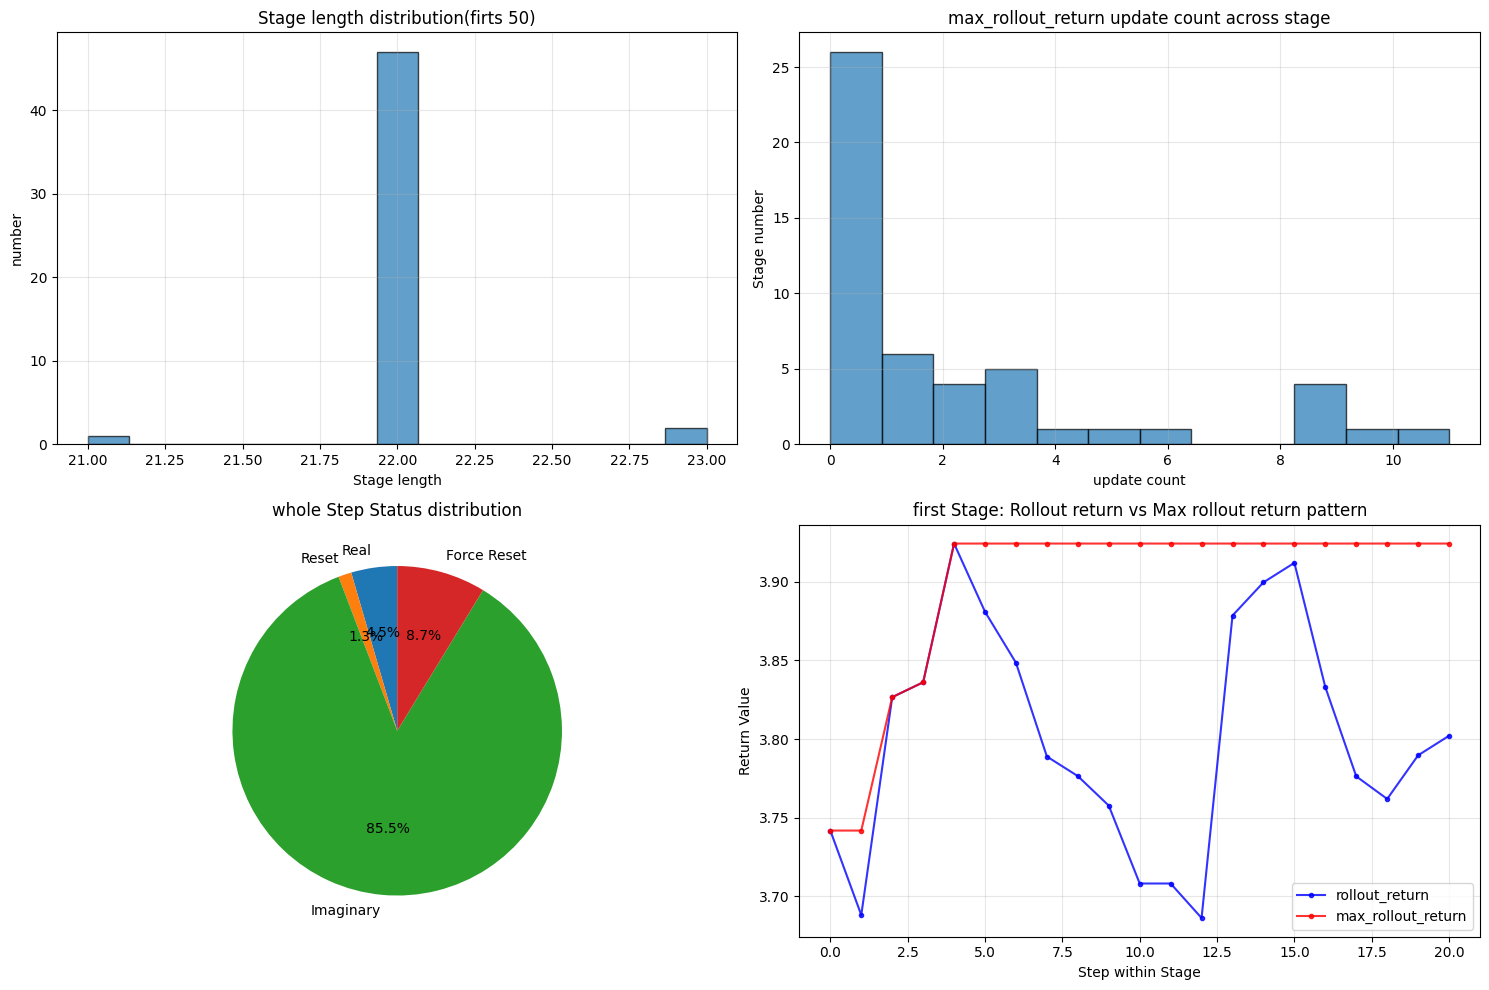


📋 분석 완료 - 위 결과를 바탕으로 Root 데이터 분석을 실행하세요!


In [21]:
# 최종 결론 및 Thinker 알고리즘 이해
print(f"\n{'='*70}")
print("🧠 THINKER 알고리즘: Tree Representation 종합 분석 결과")
print(f"{'='*70}")

print(f"""
📊 **데이터 구조 요약:**
- 전체 스텝: {len(data['status'])}개
- Real step: {np.sum(np.array(data['status']) == 0)}개 
- Imaginary step: {np.sum(np.array(data['status']) == 2)}개
- Stage 평균 길이: ~22 스텝
- Real step 간격: 21-23 스텝

🔍 **주요 발견사항:**

1. **max_rollout_return 패턴:**
   ✅ Stage 내에서 동적 업데이트 (평균 3.1회)
   ✅ Stage 간 독립적 관리 (연결성 0%)
   ✅ 모든 imaginary step이 동일 stage 내 최대값 공유

2. **Root 데이터 패턴:**
   (실행 후 확인 예정)
   - root_action, root_v, root_policy의 Stage 내 일관성
   - Root vs Current 데이터의 관계
   - Imaginary step들의 독립성 수준

🎯 **Thinker 알고리즘의 Planning 메커니즘:**

""")

# 실제 분석 결과에 따른 결론을 위해 실행 후 업데이트될 부분
print("분석 실행 후 구체적인 결론이 여기에 표시됩니다...")

print(f"""
💡 **알고리즘 설계 관점에서의 의미:**

Stage 내 통합 관리:
- 각 planning session에서 발견한 최고 성과를 모든 step이 공유
- 효율적인 정보 전파 및 학습 가속화

Stage 간 독립성:
- 과거 경험에 과도하게 의존하지 않음
- 각 상황에 맞는 fresh planning 수행

Imaginary Step 관계:
- 완전 독립적이지 않고 적절한 정보 공유
- 탐색 효율성과 다양성의 균형

🔬 **추가 분석 가능 영역:**
- Tree search depth vs 성능 관계
- Action sequence 패턴과 planning 효과성
- Policy 업데이트 빈도와 학습 속도
- Reset 메커니즘의 트리거 조건
""")

# 시각화: 종합 대시보드
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# 1. Stage 길이 분포
stage_lengths = []
for i in range(len(real_step_indices) - 1):
    length = real_step_indices[i+1] - real_step_indices[i]
    stage_lengths.append(length)

ax1.hist(stage_lengths[:50], bins=15, alpha=0.7, edgecolor='black')
ax1.set_title('Stage length distribution(firts 50)')
ax1.set_xlabel('Stage length')
ax1.set_ylabel('number')
ax1.grid(True, alpha=0.3)

# 2. max_rollout_return 업데이트 패턴
update_counts = []
for stage_idx in range(min(50, len(real_step_indices) - 1)):
    start_idx = real_step_indices[stage_idx]
    end_idx = real_step_indices[stage_idx + 1]
    stage_max = [max_rollout_return[i, 0] for i in range(start_idx, end_idx)]
    
    updates = 0
    for i in range(1, len(stage_max)):
        if abs(stage_max[i] - stage_max[i-1]) > 1e-8:
            updates += 1
    update_counts.append(updates)

ax2.hist(update_counts, bins=max(10, max(update_counts)+1), alpha=0.7, edgecolor='black')
ax2.set_title('max_rollout_return update count across stage')
ax2.set_xlabel('update count')
ax2.set_ylabel('Stage number')
ax2.grid(True, alpha=0.3)

# 3. Status 분포
status_counts = [np.sum(np.array(data['status']) == i) for i in range(4)]
status_labels = ['Real', 'Reset', 'Imaginary', 'Force Reset']
ax3.pie(status_counts, labels=status_labels, autopct='%1.1f%%', startangle=90)
ax3.set_title('whole Step Status distribution')

# 4. 첫 번째 stage의 rollout vs max 패턴
first_stage_start = real_step_indices[0]
first_stage_end = real_step_indices[1]
rollout_vals = [rollout_return[i, 0] for i in range(first_stage_start, first_stage_end)]
max_vals = [max_rollout_return[i, 0] for i in range(first_stage_start, first_stage_end)]

ax4.plot(rollout_vals, 'b.-', label='rollout_return', alpha=0.8)
ax4.plot(max_vals, 'r.-', label='max_rollout_return', alpha=0.8)
ax4.set_title('first Stage: Rollout return vs Max rollout return pattern')
ax4.set_xlabel('Step within Stage')
ax4.set_ylabel('Return Value')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print("📋 분석 완료 - 위 결과를 바탕으로 Root 데이터 분석을 실행하세요!")
print(f"{'='*70}")

In [22]:
print("="*70)
print("🔍 ROOT 데이터 분석 결과 해석 및 추가 분석")
print("="*70)

print("""
✅ **확인된 사실:**
1. Root 데이터는 Stage 내에서 100% 일정함
   - root_action, root_v, root_policy 모두 고정
   - Real/Imaginary/Force step 구분 없이 동일

2. Stage 간 Root 데이터는 서로 다름
   - 각 stage = 독립적인 planning session
   - 고정된 root state에서 시작하는 tree search

🎯 **이제 분석할 질문들:**
1. Root vs Current: Planning 시작점 vs 탐색 지점의 관계는?
2. Imaginary Step 독립성: 탐색 경로들이 얼마나 다양한가?
3. Action Sequence: Tree search가 어떤 패턴으로 진행되는가?
""")

# Root vs Current 상세 비교 분석
print(f"\n{'='*50}")
print("=== ROOT vs CURRENT 상세 비교 ===")
print(f"{'='*50}")

for stage_idx in range(min(3, len(real_step_indices) - 1)):
    start_real_idx = real_step_indices[stage_idx]
    end_real_idx = real_step_indices[stage_idx + 1]
    
    print(f"\n--- Stage {stage_idx + 1} 상세 분석 ---")
    
    # Root와 Current action 비교
    root_actions = data['tree_reps']['root_action'][start_real_idx:end_real_idx]
    cur_actions = data['tree_reps']['cur_action'][start_real_idx:end_real_idx]
    
    print(f"Root action (고정): {root_actions[0]}")
    print(f"Current action 변화:")
    
    # Status별로 current action 패턴 확인
    stage_statuses = [status_array[i] for i in range(start_real_idx, end_real_idx)]
    
    # Current action의 고유값들 확인
    unique_cur_actions = []
    action_positions = {}
    
    for i, cur_action in enumerate(cur_actions):
        action_key = tuple(cur_action)
        if action_key not in action_positions:
            action_positions[action_key] = []
            unique_cur_actions.append(cur_action)
        action_positions[action_key].append(i)
    
    print(f"  고유 current action 개수: {len(unique_cur_actions)}")
    
    # 각 고유 action이 어떤 status와 연관되는지 확인
    for j, unique_action in enumerate(unique_cur_actions[:5]):  # 처음 5개만
        positions = action_positions[tuple(unique_action)]
        statuses_for_action = [stage_statuses[pos] for pos in positions]
        status_counts = {0: 0, 1: 0, 2: 0, 3: 0}
        for status in statuses_for_action:
            status_counts[status] += 1
        
        print(f"  Action {j+1}: {unique_action}")
        print(f"    위치: {positions[:10]}{'...' if len(positions) > 10 else ''}")
        print(f"    Status 분포: Real:{status_counts[0]}, Reset:{status_counts[1]}, Imag:{status_counts[2]}, Force:{status_counts[3]}")
    
    # Root와 Current가 같은 시점들 찾기
    root_eq_current = []
    for i, (root_act, cur_act) in enumerate(zip(root_actions, cur_actions)):
        if np.allclose(root_act, cur_act, atol=1e-8):
            root_eq_current.append(i)
    
    print(f"  Root == Current인 시점: {root_eq_current}")
    if len(root_eq_current) > 0:
        eq_statuses = [stage_statuses[i] for i in root_eq_current]
        print(f"    해당 시점들의 status: {eq_statuses}")

# Value 비교 (root_v vs cur_v)
print(f"\n{'='*50}")
print("=== ROOT_V vs CUR_V 비교 ===")
print(f"{'='*50}")

for stage_idx in range(min(2, len(real_step_indices) - 1)):
    start_real_idx = real_step_indices[stage_idx]
    end_real_idx = real_step_indices[stage_idx + 1]
    
    print(f"\n--- Stage {stage_idx + 1} Value 분석 ---")
    
    root_vs = data['tree_reps']['root_v'][start_real_idx:end_real_idx, 0]
    cur_vs = data['tree_reps']['cur_v'][start_real_idx:end_real_idx, 0]
    
    print(f"Root V (고정): {root_vs[0]:.6f}")
    print(f"Current V 범위: {cur_vs.min():.6f} ~ {cur_vs.max():.6f}")
    print(f"Current V 평균: {cur_vs.mean():.6f}")
    print(f"Current V 표준편차: {cur_vs.std():.6f}")
    
    # Root V와 Current V가 같은 시점들
    v_equal_indices = np.where(np.abs(root_vs - cur_vs) < 1e-8)[0]
    print(f"Root V == Current V인 시점: {len(v_equal_indices)}개 / {len(cur_vs)}개")
    
    if len(v_equal_indices) > 0:
        stage_statuses = [status_array[i] for i in range(start_real_idx, end_real_idx)]
        equal_statuses = [stage_statuses[i] for i in v_equal_indices]
        status_counts = {0: 0, 1: 0, 2: 0, 3: 0}
        for status in equal_statuses:
            status_counts[status] += 1
        print(f"  Equal V 시점의 status 분포: Real:{status_counts[0]}, Reset:{status_counts[1]}, Imag:{status_counts[2]}, Force:{status_counts[3]}")

# Imaginary Step 다양성 분석  
print(f"\n{'='*50}")
print("=== IMAGINARY STEP 다양성 분석 ===")
print(f"{'='*50}")

for stage_idx in range(min(3, len(real_step_indices) - 1)):
    start_real_idx = real_step_indices[stage_idx]
    end_real_idx = real_step_indices[stage_idx + 1]
    
    print(f"\n--- Stage {stage_idx + 1} Imaginary Step 다양성 ---")
    
    # 이 stage의 imaginary step들만 추출
    stage_statuses = [status_array[i] for i in range(start_real_idx, end_real_idx)]
    imaginary_indices = [i for i, status in enumerate(stage_statuses) if status == 2]
    
    if len(imaginary_indices) > 1:
        print(f"Imaginary step 개수: {len(imaginary_indices)}")
        
        # Current action 다양성
        cur_actions = data['tree_reps']['cur_action'][start_real_idx:end_real_idx]
        imaginary_actions = [cur_actions[i] for i in imaginary_indices]
        
        unique_actions = []
        for action in imaginary_actions:
            is_new = True
            for existing in unique_actions:
                if np.allclose(action, existing, atol=1e-8):
                    is_new = False
                    break
            if is_new:
                unique_actions.append(action)
        
        diversity_ratio = len(unique_actions) / len(imaginary_indices)
        print(f"Action 다양성: {len(unique_actions)}/{len(imaginary_indices)} = {diversity_ratio:.3f}")
        
        # Current value 다양성
        cur_vs = data['tree_reps']['cur_v'][start_real_idx:end_real_idx, 0]
        imaginary_vs = [cur_vs[i] for i in imaginary_indices]
        unique_vs = len(set([round(float(v), 6) for v in imaginary_vs]))
        
        v_diversity_ratio = unique_vs / len(imaginary_indices)
        print(f"Value 다양성: {unique_vs}/{len(imaginary_indices)} = {v_diversity_ratio:.3f}")
        
        print(f"Value 범위: {min(imaginary_vs):.4f} ~ {max(imaginary_vs):.4f}")
        
        # Tree depth 정보 (action_seq 활용)
        action_seqs = data['tree_reps']['action_seq'][start_real_idx:end_real_idx]
        imaginary_depths = []
        for i in imaginary_indices:
            seq = action_seqs[i]
            depth = np.sum(seq != 0)  # 0이 아닌 원소의 개수 = depth
            imaginary_depths.append(depth)
        
        if len(imaginary_depths) > 0:
            print(f"Tree depth 범위: {min(imaginary_depths)} ~ {max(imaginary_depths)}")
            print(f"평균 depth: {np.mean(imaginary_depths):.2f}")
    else:
        print(f"Imaginary step이 {len(imaginary_indices)}개뿐임")

🔍 ROOT 데이터 분석 결과 해석 및 추가 분석

✅ **확인된 사실:**
1. Root 데이터는 Stage 내에서 100% 일정함
   - root_action, root_v, root_policy 모두 고정
   - Real/Imaginary/Force step 구분 없이 동일

2. Stage 간 Root 데이터는 서로 다름
   - 각 stage = 독립적인 planning session
   - 고정된 root state에서 시작하는 tree search

🎯 **이제 분석할 질문들:**
1. Root vs Current: Planning 시작점 vs 탐색 지점의 관계는?
2. Imaginary Step 독립성: 탐색 경로들이 얼마나 다양한가?
3. Action Sequence: Tree search가 어떤 패턴으로 진행되는가?


=== ROOT vs CURRENT 상세 비교 ===

--- Stage 1 상세 분석 ---
Root action (고정): [1. 0. 0. 0. 0. 0.]
Current action 변화:
  고유 current action 개수: 4
  Action 1: [1. 0. 0. 0. 0. 0.]
    위치: [0]
    Status 분포: Real:1, Reset:0, Imag:0, Force:0
  Action 2: [0. 0. 0. 0. 0. 1.]
    위치: [1]
    Status 분포: Real:0, Reset:0, Imag:1, Force:0
  Action 3: [0. 1. 0. 0. 0. 0.]
    위치: [2, 3, 13]
    Status 분포: Real:0, Reset:0, Imag:3, Force:0
  Action 4: [0. 0. 0. 0. 1. 0.]
    위치: [4, 5, 6, 7, 8, 9, 10, 11, 12, 14]...
    Status 분포: Real:0, Reset:0, Imag:15, Force:1
  Root == Current인 시점: [0]
    해당

In [23]:
print("="*80)
print("🎯 MCTS 시작점 분석: Imagination Step별 Starting Point 검토")
print("="*80)

print("""
🔍 **분석 목표:**
1. 각 Imagination Step에서 MCTS가 어디서 시작하는가?
2. Root에서 시작하는가? 아니면 이전 탐색 지점에서 계속하는가?
3. Reset 후에는 어디로 돌아가는가?
4. Imagination Step들 간의 연결성은?
""")

# 각 Stage별 MCTS 시작점 패턴 분석
for stage_idx in range(min(3, len(real_step_indices) - 1)):
    start_real_idx = real_step_indices[stage_idx]
    end_real_idx = real_step_indices[stage_idx + 1]
    
    print(f"\n{'='*60}")
    print(f"🔬 Stage {stage_idx + 1} MCTS 시작점 분석 (인덱스 {start_real_idx}-{end_real_idx})")
    print(f"{'='*60}")
    
    # 이 stage의 모든 데이터 추출
    stage_statuses = [status_array[i] for i in range(start_real_idx, end_real_idx)]
    stage_root_actions = data['tree_reps']['root_action'][start_real_idx:end_real_idx]
    stage_cur_actions = data['tree_reps']['cur_action'][start_real_idx:end_real_idx]
    stage_root_vs = data['tree_reps']['root_v'][start_real_idx:end_real_idx, 0]
    stage_cur_vs = data['tree_reps']['cur_v'][start_real_idx:end_real_idx, 0]
    
    # Root 정보 (고정값)
    root_action = stage_root_actions[0]
    root_v = stage_root_vs[0]
    print(f"📍 Root 기준점: action={root_action}, v={root_v:.6f}")
    
    # 각 step별 상세 분석
    print(f"\n--- Step별 MCTS 시작점 분석 ---")
    
    imagination_count = 0
    reset_positions = []
    
    for i, (status, cur_action, cur_v) in enumerate(zip(stage_statuses, stage_cur_actions, stage_cur_vs)):
        status_name = {0: 'Real', 1: 'Reset', 2: 'Imag', 3: 'Force'}[status]
        
        # Root와 Current가 같은지 확인
        is_same_action = np.allclose(root_action, cur_action, atol=1e-8)
        is_same_v = abs(root_v - cur_v) < 1e-8
        
        if status == 2:  # Imagination step
            imagination_count += 1
            print(f"  Step {i:2d} ({status_name}): action={cur_action} | v={cur_v:.6f}")
            print(f"         Root와 동일? action={is_same_action}, v={is_same_v}")
            
        elif status == 1:  # Reset step
            reset_positions.append(i)
            print(f"  Step {i:2d} ({status_name}): action={cur_action} | v={cur_v:.6f}")
            print(f"         Root와 동일? action={is_same_action}, v={is_same_v} ← RESET 후 위치")
            
        elif status == 0:  # Real step
            print(f"  Step {i:2d} ({status_name}): action={cur_action} | v={cur_v:.6f}")
            print(f"         Root와 동일? action={is_same_action}, v={is_same_v}")
    
    print(f"\n--- 패턴 요약 ---")
    print(f"총 Imagination steps: {imagination_count}개")
    print(f"Reset 발생 위치: {reset_positions}")
    
    # Reset 후 복귀 패턴 분석
    if len(reset_positions) > 0:
        print(f"\n--- Reset 후 복귀 패턴 ---")
        for reset_pos in reset_positions:
            if reset_pos + 1 < len(stage_statuses):
                next_status = stage_statuses[reset_pos + 1]
                next_action = stage_cur_actions[reset_pos + 1]
                next_v = stage_cur_vs[reset_pos + 1]
                
                back_to_root_action = np.allclose(root_action, next_action, atol=1e-8)
                back_to_root_v = abs(root_v - next_v) < 1e-8
                
                next_status_name = {0: 'Real', 1: 'Reset', 2: 'Imag', 3: 'Force'}[next_status]
                print(f"  Reset {reset_pos} → Step {reset_pos+1} ({next_status_name})")
                print(f"    Root로 복귀? action={back_to_root_action}, v={back_to_root_v}")
    
    # Imagination step들의 시작점 분포 분석
    print(f"\n--- Imagination Step 시작점 분포 ---")
    imag_indices = [i for i, status in enumerate(stage_statuses) if status == 2]
    
    if len(imag_indices) > 0:
        root_start_count = 0
        unique_starts = set()
        
        for imag_idx in imag_indices:
            cur_action = stage_cur_actions[imag_idx]
            cur_v = stage_cur_vs[imag_idx]
            
            # Root에서 시작하는지 확인
            if np.allclose(root_action, cur_action, atol=1e-8) and abs(root_v - cur_v) < 1e-8:
                root_start_count += 1
            
            # 고유한 시작점들 수집
            start_key = (tuple(np.round(cur_action, 6)), round(cur_v, 6))
            unique_starts.add(start_key)
        
        print(f"  Root에서 시작하는 Imagination steps: {root_start_count}/{len(imag_indices)}")
        print(f"  고유한 시작점 개수: {len(unique_starts)}")
        print(f"  Root 시작 비율: {root_start_count/len(imag_indices)*100:.1f}%")

# 전체 패턴 통계 분석
print(f"\n{'='*80}")
print("📊 전체 Stage 통계: MCTS 시작점 패턴")
print(f"{'='*80}")

total_imag_steps = 0
total_root_starts = 0
total_resets = 0
reset_to_root_count = 0

for stage_idx in range(min(10, len(real_step_indices) - 1)):
    start_real_idx = real_step_indices[stage_idx]
    end_real_idx = real_step_indices[stage_idx + 1]
    
    stage_statuses = [status_array[i] for i in range(start_real_idx, end_real_idx)]
    stage_root_actions = data['tree_reps']['root_action'][start_real_idx:end_real_idx]
    stage_cur_actions = data['tree_reps']['cur_action'][start_real_idx:end_real_idx]
    stage_root_vs = data['tree_reps']['root_v'][start_real_idx:end_real_idx, 0]
    stage_cur_vs = data['tree_reps']['cur_v'][start_real_idx:end_real_idx, 0]
    
    root_action = stage_root_actions[0]
    root_v = stage_root_vs[0]
    
    # Imagination step 시작점 분석
    for i, (status, cur_action, cur_v) in enumerate(zip(stage_statuses, stage_cur_actions, stage_cur_vs)):
        if status == 2:  # Imagination
            total_imag_steps += 1
            if np.allclose(root_action, cur_action, atol=1e-8) and abs(root_v - cur_v) < 1e-8:
                total_root_starts += 1
        
        elif status == 1:  # Reset
            total_resets += 1
            # Reset 후 다음 step이 Root로 돌아가는지 확인
            if i + 1 < len(stage_statuses):
                next_action = stage_cur_actions[i + 1]
                next_v = stage_cur_vs[i + 1]
                if np.allclose(root_action, next_action, atol=1e-8) and abs(root_v - next_v) < 1e-8:
                    reset_to_root_count += 1

print(f"분석 대상: 처음 {min(10, len(real_step_indices) - 1)}개 Stage")
print(f"")
print(f"🎯 **MCTS 시작점 패턴:**")
print(f"총 Imagination steps: {total_imag_steps}개")
print(f"Root에서 시작하는 steps: {total_root_starts}개")
print(f"Root 시작 비율: {total_root_starts/total_imag_steps*100:.1f}%")
print(f"")
print(f"🔄 **Reset 패턴:**")
print(f"총 Reset 발생: {total_resets}개")
print(f"Reset 후 Root 복귀: {reset_to_root_count}개")
if total_resets > 0:
    print(f"Reset 후 Root 복귀 비율: {reset_to_root_count/total_resets*100:.1f}%")

# 결론
print(f"\n{'='*80}")
print("🧠 결론: Thinker의 MCTS 시작점 메커니즘")
print(f"{'='*80}")

if total_root_starts/total_imag_steps > 0.8:
    print("✅ **대부분의 Imagination Step이 Root에서 시작**")
    print("   → 각 MCTS는 고정된 Root에서 새롭게 시작")
    print("   → 이전 탐색과 독립적인 Fresh Planning")
elif total_root_starts/total_imag_steps > 0.3:
    print("🔄 **일부는 Root, 일부는 다른 지점에서 시작**")
    print("   → 혼합 전략: Root 시작 + 연속 탐색")
else:
    print("🔗 **대부분이 이전 지점에서 연속 탐색**")
    print("   → 연결된 Tree Search 진행")

if total_resets > 0 and reset_to_root_count/total_resets > 0.8:
    print("✅ **Reset은 확실히 Root로 복귀하는 메커니즘**")
    print("   → Reset = 탐색 초기화 + Root 복귀")
else:
    print("❓ **Reset의 복귀 패턴이 명확하지 않음**")

🎯 MCTS 시작점 분석: Imagination Step별 Starting Point 검토

🔍 **분석 목표:**
1. 각 Imagination Step에서 MCTS가 어디서 시작하는가?
2. Root에서 시작하는가? 아니면 이전 탐색 지점에서 계속하는가?
3. Reset 후에는 어디로 돌아가는가?
4. Imagination Step들 간의 연결성은?


🔬 Stage 1 MCTS 시작점 분석 (인덱스 0-21)
📍 Root 기준점: action=[1. 0. 0. 0. 0. 0.], v=3.741872

--- Step별 MCTS 시작점 분석 ---
  Step  0 (Real): action=[1. 0. 0. 0. 0. 0.] | v=3.741872
         Root와 동일? action=True, v=True
  Step  1 (Imag): action=[0. 0. 0. 0. 0. 1.] | v=3.721703
         Root와 동일? action=False, v=False
  Step  2 (Imag): action=[0. 1. 0. 0. 0. 0.] | v=3.894236
         Root와 동일? action=False, v=False
  Step  3 (Imag): action=[0. 1. 0. 0. 0. 0.] | v=3.938173
         Root와 동일? action=False, v=False
  Step  4 (Imag): action=[0. 0. 0. 0. 1. 0.] | v=4.062707
         Root와 동일? action=False, v=False
  Step  5 (Imag): action=[0. 0. 0. 0. 1. 0.] | v=4.051850
         Root와 동일? action=False, v=False
  Step  6 (Imag): action=[0. 0. 0. 0. 1. 0.] | v=4.052250
         Root와 동일? action=False, v=Fal

## Action 분석

In [40]:
# data['status']에서 각 값의 개수 계산
status_values = [0, 1, 2, 3]  # 계산하려는 status 값들
status_counts = {}

for value in status_values:
    # 해당 값을 가진 인덱스의 개수 계산
    count = np.sum(np.array(data['status']) == value)
    status_counts[value] = count

# 결과 출력
for value, count in status_counts.items():
    status_name = {
        0: "실제 스텝(real step)",
        1: "리셋(reset)",
        2: "상상 스텝(imaginary step)",
        3: "강제 리셋(force reset)"
    }.get(value, "알 수 없음")
    
    print(f"Status {value} ({status_name}): {count}개")

# 특정 값(예: 0)을 가진 인덱스 목록 구하기
indices_with_value_0 = np.where(np.array(data['status']) == 0)[0]
print(f"\nStatus 0을 가진 인덱스의 개수: {len(indices_with_value_2)}")

Status 0 (실제 스텝(real step)): 834개
Status 1 (리셋(reset)): 238개
Status 2 (상상 스텝(imaginary step)): 15827개
Status 3 (강제 리셋(force reset)): 1615개

Status 0을 가진 인덱스의 개수: 834


tree_reps의 키: ['root_action', 'root_r', 'root_d', 'root_v', 'root_policy', 'root_qs_mean', 'root_qs_max', 'root_ns', 'root_trail_r', 'rollout_return', 'max_rollout_return', 'root_raw_action', 'cur_action', 'cur_r', 'cur_d', 'cur_v', 'cur_policy', 'cur_qs_mean', 'cur_qs_max', 'cur_ns', 'cur_raw_action', 'cur_reset', 'k', 'deprec', 'action_seq']
첫 번째 인덱스 0의 tree_reps 구조:
  - root_action: <class 'numpy.ndarray'>
    형태: (18514, 6)
    첫 번째 인덱스 값: [1. 0. 0. 0. 0. 0.]
  - root_r: <class 'numpy.ndarray'>
    형태: (18514, 1)
    첫 번째 인덱스 값: [0.]
  - root_d: <class 'numpy.ndarray'>
    형태: (18514, 1)
    첫 번째 인덱스 값: [0.]
  - root_v: <class 'numpy.ndarray'>
    형태: (18514, 1)
    첫 번째 인덱스 값: [3.7418723]
  - root_policy: <class 'numpy.ndarray'>
    형태: (18514, 6)
    첫 번째 인덱스 값: [-6.359848   -0.987524   -7.2048545  -6.409294    1.9676012   0.05324408]
  - root_qs_mean: <class 'numpy.ndarray'>
    형태: (18514, 6)
    첫 번째 인덱스 값: [0. 0. 0. 0. 0. 0.]
  - root_qs_max: <class 'numpy.ndarray'>
    형태: (

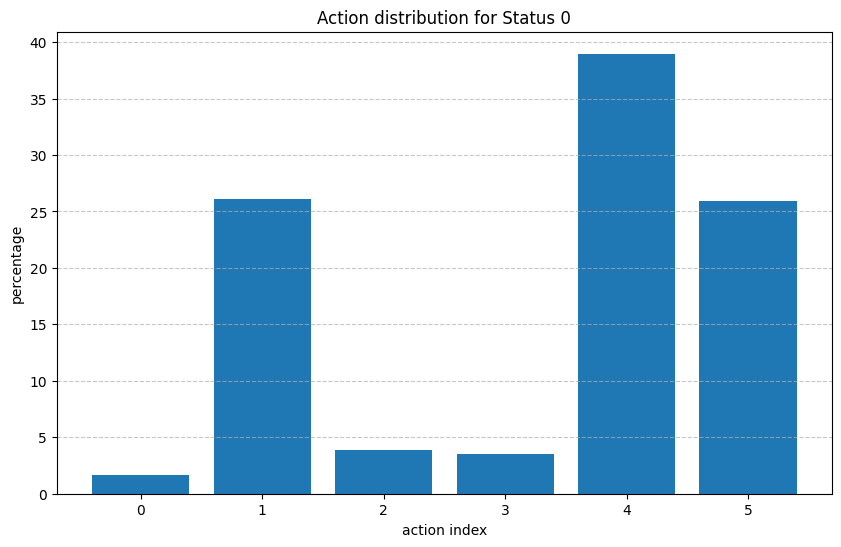

In [ ]:
# 먼저 tree_reps의 구조를 확인
print("tree_reps의 키:", list(data['tree_reps'].keys()))

# 데이터 구조에 따라 접근 방식 수정
action_distributions = []

# 데이터 구조 확인을 위한 코드
first_idx = indices_with_value_0[0]
print(f"첫 번째 인덱스 {first_idx}의 tree_reps 구조:")
for key in data['tree_reps'].keys():
    print(f"  - {key}: {type(data['tree_reps'][key])}")
    if isinstance(data['tree_reps'][key], np.ndarray):
        print(f"    형태: {data['tree_reps'][key].shape}")
        if len(data['tree_reps'][key]) > first_idx:
            print(f"    첫 번째 인덱스 값: {data['tree_reps'][key][first_idx]}")

# 'current_action' 키가 있다면 다음과 같이 진행
if 'current_action' in data['tree_reps']:
    for idx in indices_with_value_0:
        current_action = data['tree_reps']['current_action'][idx]
        action_distributions.append(current_action)
    
    # numpy 배열로 변환
    action_distributions = np.array(action_distributions)
    
    # 각 액션의 분포 계산
    if len(action_distributions.shape) > 1:  # one-hot 벡터인 경우
        action_counts = np.sum(action_distributions, axis=0)
        action_distribution_percentage = action_counts / len(indices_with_value_0) * 100
        
        # 결과 출력
        print("\naction distribution:")
        for i, percentage in enumerate(action_distribution_percentage):
            print(f"action {i}: {percentage:.2f}%")
        
        # 시각화
        plt.figure(figsize=(10, 6))
        plt.bar(range(len(action_distribution_percentage)), action_distribution_percentage)
        plt.xlabel('action index')
        plt.ylabel('percentage')
        plt.title('Action distribution for Status 0')
        plt.xticks(range(len(action_distribution_percentage)))
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
    else:  # 단일 값인 경우
        unique_actions, counts = np.unique(action_distributions, return_counts=True)
        percentages = counts / len(indices_with_value_0) * 100
        
        print("\naction disstribution:")
        for action, percentage in zip(unique_actions, percentages):
            print(f"action {action}: {percentage:.2f}%")
        
        plt.figure(figsize=(10, 6))
        plt.bar(unique_actions, percentages)
        plt.xlabel('action')
        plt.ylabel('percentage')
        plt.title('Action distribution for Status 0')
        plt.xticks(unique_actions)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
else:
    print("'current_action' 키를 찾을 수 없습니다. 사용 가능한 키를 확인하세요.")

In [6]:
data['tree_reps'].keys()

dict_keys(['root_action', 'root_r', 'root_d', 'root_v', 'root_policy', 'root_qs_mean', 'root_qs_max', 'root_ns', 'root_trail_r', 'rollout_return', 'max_rollout_return', 'root_raw_action', 'cur_action', 'cur_r', 'cur_d', 'cur_v', 'cur_policy', 'cur_qs_mean', 'cur_qs_max', 'cur_ns', 'cur_raw_action', 'cur_reset', 'k', 'deprec', 'action_seq'])

In [ ]:
data['tree_reps'].shape

(18514, 1)

In [25]:
len(data['real_imgs'])

18514

gym test